In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("/content/fruit_classification_dataset.csv")
df.head()

,size (cm),shape,weight (g),avg_price (₹),color,taste,fruit_name
0,25.4,round,3089.2,137.1,green,sweet,watermelon
1,24.6,round,3283.9,163.8,green,sweet,watermelon
2,7.8,round,319.0,91.3,green,sweet,custard apple
3,20.0,oval,1607.0,85.7,orange,sweet,papaya
4,10.2,long,131.5,37.8,yellow,sweet,banana


In [ ]:
df["fruit_name"].value_counts()

,count
fruit_name,
pear,534
pomegranate,534
pineapple,533
custard apple,516
papaya,509
kiwi,506
blueberry,503
banana,502
coconut,502


In [ ]:
df.shape

(10000, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   size (cm)      10000 non-null  float64
 1   shape          10000 non-null  object 
 2   weight (g)     10000 non-null  float64
 3   avg_price (₹)  10000 non-null  float64
 4   color          10000 non-null  object 
 5   taste          10000 non-null  object 
 6   fruit_name     10000 non-null  object 
dtypes: float64(3), object(4)
memory usage: 547.0+ KB


In [ ]:
df.describe()

,size (cm),weight (g),avg_price (₹)
count,10000.000000,10000.000000,10000.000000
mean,8.430600,455.457720,77.016720
std,6.396915,731.643087,38.946916
min,0.900000,4.500000,9.000000
25%,3.700000,45.800000,45.575000
50%,7.200000,168.800000,75.400000
75%,10.100000,365.275000,100.700000
max,27.500000,3299.800000,165.000000


In [ ]:
df.duplicated().sum()

np.int64(246)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.head()

,size (cm),shape,weight (g),avg_price (₹),color,taste,fruit_name
0,25.4,round,3089.2,137.1,green,sweet,watermelon
1,24.6,round,3283.9,163.8,green,sweet,watermelon
2,7.8,round,319.0,91.3,green,sweet,custard apple
3,20.0,oval,1607.0,85.7,orange,sweet,papaya
4,10.2,long,131.5,37.8,yellow,sweet,banana


<Axes: title={'center': 'Shape'}, xlabel='shape'>

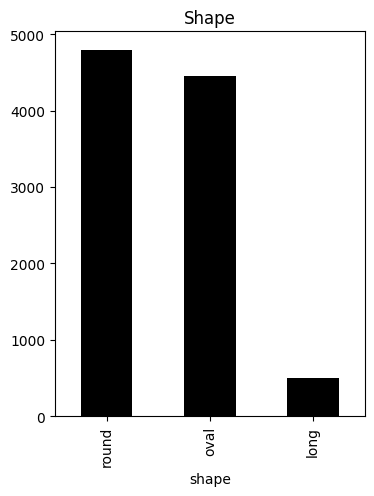

In [ ]:
df["shape"].value_counts().head().plot(
    kind='bar',
    color='black',
    figsize=(4,5),   # مهم: tuple
    title="Shape")

<Axes: title={'center': 'THE MOST COLOR EXIST'}, xlabel='color'>

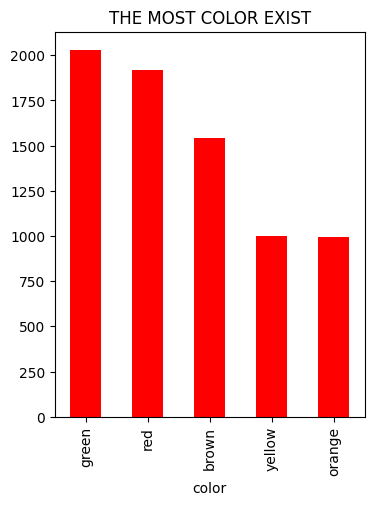

In [ ]:
df["color"].value_counts().head().plot(
    kind='bar',
    color='red',
    figsize=(4,5),   # مهم: tuple
    title="THE MOST COLOR EXIST")

<Axes: title={'center': 'Counts of Fruit'}, xlabel='fruit_name'>

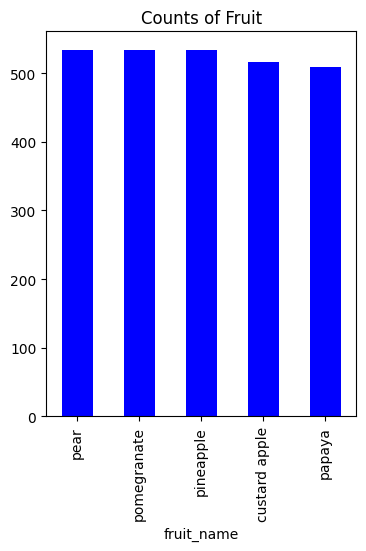

In [ ]:
df["fruit_name"].value_counts().head().plot(
    kind='bar',
    color='blue',
    figsize=(4,5),
    title="Counts of Fruit"
)


In [ ]:
df["taste"].value_counts()

,count
taste,
sweet,7261
tangy,2012
sour,481


<Axes: title={'center': 'Taste'}, xlabel='taste'>

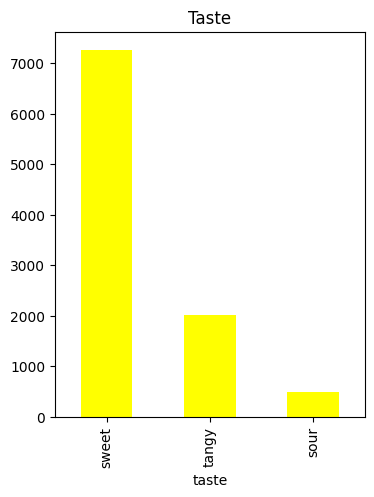

In [ ]:
df["taste"].value_counts().head().plot(
    kind='bar',
    color='yellow',
    figsize=(4,5),
    title="Taste"
)

In [ ]:
numeric=df.select_dtypes(include=['Int64','Float64']).columns
numeric

Index(['size (cm)', 'weight (g)', 'avg_price (₹)'], dtype='object')

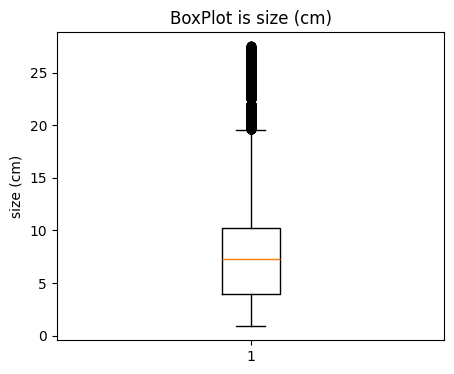

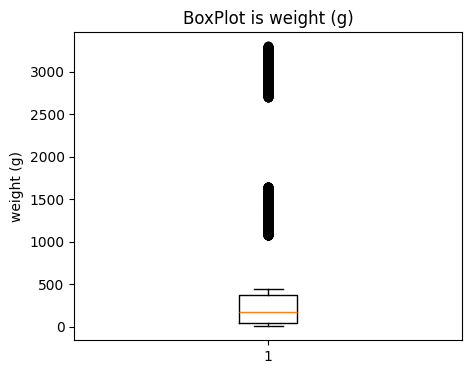

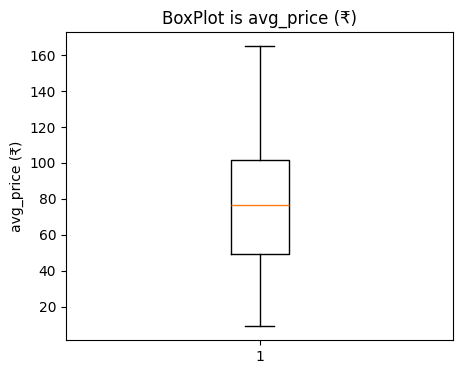

In [ ]:
for col in numeric:

     plt.figure(figsize=(5,4))
     plt.boxplot(df[col])
     plt.title(f'BoxPlot is {col}')
     plt.ylabel(col)
     plt.show()

In [ ]:
for col in numeric:
  q1=df[col].quantile(0.25)
  q3=df[col].quantile(0.75)
  iqr=q3-q1
  lower=q1-(1.5*iqr)
  upper=q3+(1.5*iqr)
  outlier=df[(df[col]<lower)| (df[col]>upper)]
  outlier_percentage=(len(outlier)/len(df))/100
  print(f"outlier_percentage of {col} :{outlier_percentage}, Number_outlier :{len(outlier)}")

outlier_percentage of size (cm) :0.0008878408857904449, Number_outlier :866
outlier_percentage of weight (g) :0.0020935001025220424, Number_outlier :2042
outlier_percentage of avg_price (₹) :0.0, Number_outlier :0


In [ ]:
columns = ['size (cm)', 'weight (g)']
for col in columns:
    df[col] = np.log1p(df[col])



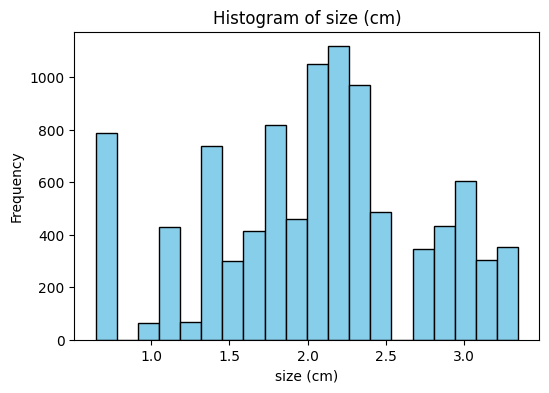

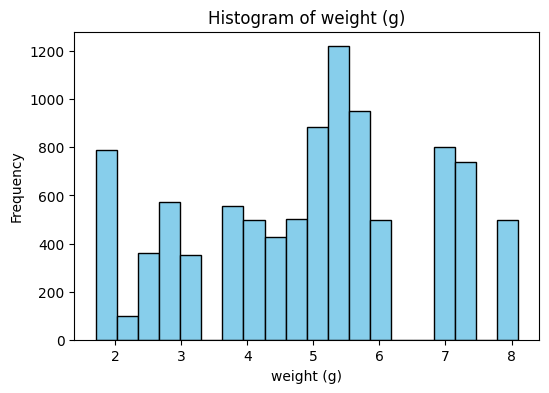

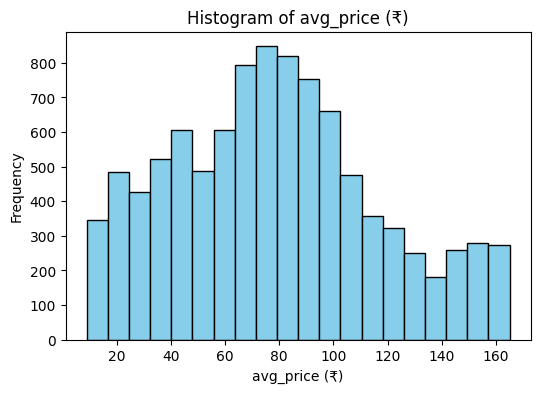

In [ ]:
for col in numeric:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


In [ ]:
x=df.drop(columns=["fruit_name"])
y=df["fruit_name"]

In [ ]:
y.value_counts()

,count
fruit_name,
pear,534
pomegranate,534
pineapple,533
custard apple,516
papaya,509
kiwi,506
coconut,502
banana,502
mango,500


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import  StandardScaler,LabelEncoder


In [ ]:
x_train,x_test, y_train,y_test =train_test_split(x,y,random_state=42,test_size=0.3)

In [ ]:
cat_features = x_train.select_dtypes(include=['object']).columns.tolist()

In [ ]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=100,
    learning_rate=0.05,
    depth=6,
    loss_function='MultiClass',
    verbose=100
)
model.fit(x_train, y_train, cat_features=cat_features)

0:	learn: 2.4687261	total: 926ms	remaining: 1m 31s
99:	learn: 0.0407029	total: 57s	remaining: 0us


CatBoostClassifier(depth=6, iterations=100, learning_rate=0.05, loss_function='MultiClass', verbose=100)

In [ ]:
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)


In [ ]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 1.0


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

        apple       1.00      1.00      1.00       142
       banana       1.00      1.00      1.00       150
    blueberry       1.00      1.00      1.00       134
       cherry       1.00      1.00      1.00       135
      coconut       1.00      1.00      1.00       150
custard apple       1.00      1.00      1.00       158
 dragon fruit       1.00      1.00      1.00       152
        grape       1.00      1.00      1.00       104
        guava       1.00      1.00      1.00       139
         kiwi       1.00      1.00      1.00       157
       lychee       1.00      1.00      1.00       130
        mango       1.00      1.00      1.00       131
       orange       1.00      1.00      1.00       143
       papaya       1.00      1.00      1.00       145
         pear       1.00      1.00      1.00       166
    pineapple       1.00      1.00      1.00       162
         plum       1.00      1.00      1.00       159
  pomegra

In [ ]:
from catboost import cv, Pool

cv_data = cv(
    Pool(data=x_train, label=y_train, cat_features=cat_features),
    params=model.get_params(),
    fold_count=5
)

Training on fold [0/5]
0:	learn: 2.4667530	test: 2.4596410	best: 2.4596410 (0)	total: 471ms	remaining: 46.6s
99:	learn: 0.0372522	test: 0.0320457	best: 0.0320457 (99)	total: 56.7s	remaining: 0us

bestTest = 0.03204571293
bestIteration = 99

Training on fold [1/5]
0:	learn: 2.5600451	test: 2.5554035	best: 2.5554035 (0)	total: 364ms	remaining: 36.1s
99:	learn: 0.0398224	test: 0.0354416	best: 0.0354416 (99)	total: 40s	remaining: 0us

bestTest = 0.03544163038
bestIteration = 99

Training on fold [2/5]
0:	learn: 2.4435720	test: 2.4429835	best: 2.4429835 (0)	total: 399ms	remaining: 39.5s
99:	learn: 0.0400444	test: 0.0353667	best: 0.0353667 (99)	total: 39.8s	remaining: 0us

bestTest = 0.03536669444
bestIteration = 99

Training on fold [3/5]
0:	learn: 2.4988996	test: 2.4968169	best: 2.4968169 (0)	total: 369ms	remaining: 36.5s
99:	learn: 0.0377753	test: 0.0316227	best: 0.0316227 (99)	total: 39.4s	remaining: 0us

bestTest = 0.03162274449
bestIteration = 99

Training on fold [4/5]
0:	learn: 2.650

In [ ]:
model.get_feature_importance(prettified=True)

,Feature Id,Importances
0,shape,31.567908
1,avg_price (₹),23.354308
2,weight (g),18.923516
3,size (cm),15.971883
4,color,5.523473
5,taste,4.658914


In [ ]:
print(cv_data.columns.tolist())

['iterations', 'test-MultiClass-mean', 'test-MultiClass-std', 'train-MultiClass-mean', 'train-MultiClass-std']


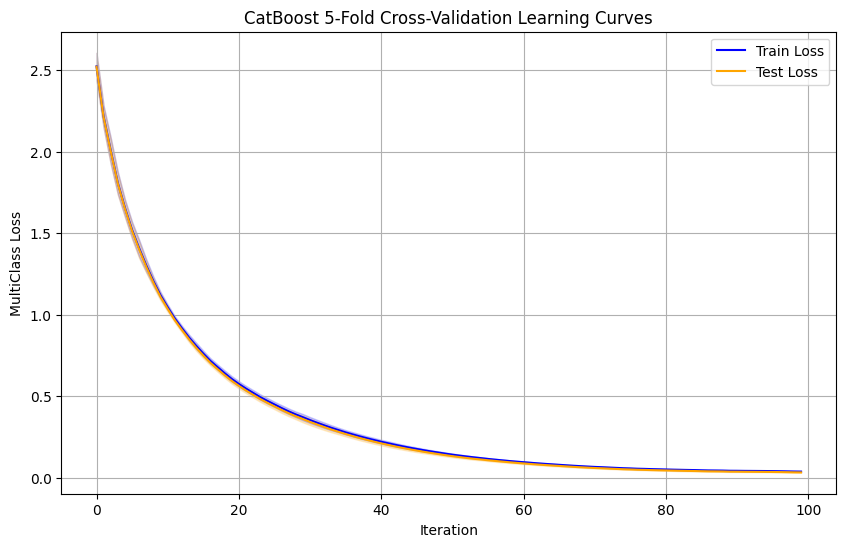

In [ ]:

plt.figure(figsize=(10,6))

plt.plot(cv_data['train-MultiClass-mean'], label='Train Loss', color='blue')
plt.fill_between(range(len(cv_data)),
                 cv_data['train-MultiClass-mean'] - cv_data['train-MultiClass-std'],
                 cv_data['train-MultiClass-mean'] + cv_data['train-MultiClass-std'],
                 color='blue', alpha=0.2)

plt.plot(cv_data['test-MultiClass-mean'], label='Test Loss', color='orange')
plt.fill_between(range(len(cv_data)),
                 cv_data['test-MultiClass-mean'] - cv_data['test-MultiClass-std'],
                 cv_data['test-MultiClass-mean'] + cv_data['test-MultiClass-std'],
                 color='orange', alpha=0.2)

plt.xlabel('Iteration')
plt.ylabel('MultiClass Loss')
plt.title('CatBoost 5-Fold Cross-Validation Learning Curves')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
 ## new data
import pandas as pd

new_data = pd.DataFrame({
    'size (cm)': [15, 20],
    'shape': [1, 0],
    'weight (g)': [150, 200],
    'avg_price (₹)': [50, 70],
    'color': [2, 3],
    'taste': [1, 0]
})


In [ ]:
y_new_pred = model.predict(new_data)
y_new_prob = model.predict_proba(new_data)

print("Predicted Fruits:", y_new_pred)


Predicted Fruits: [['guava']
 ['coconut']]
